<a href="https://colab.research.google.com/github/G-Assimila/pvlncc2026/blob/main/notebooks/NN_KF_LNCC_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Workshop da Escola de Verão do Laboratório Nacional de Computação Científica (LNCC)

###Mini-curso: Assimilação de Dados por Aprendizado de Máquina


####Neste notebook iremos desenvolver um modelo baseado em Redes Neurias para emular o Filtro de Kalman (KF) para o Sistema de Lorenz

#### Esta atividade se baseia na anterior, onde executamos o KF para mesma aplicação

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

### Download do conjunto de dados

In [ ]:
!gdown https://drive.google.com/uc?id=1eUidnBlkRuR5rgufh7S0qrq1un1m001j

Downloading...
From: https://drive.google.com/uc?id=1eUidnBlkRuR5rgufh7S0qrq1un1m001j
To: /content/lorenz_kalman_dataset_updated_correct.csv
100% 2.44M/2.44M [00:00<00:00, 153MB/s]


### Função auxiliar

In [ ]:
def create_sequences(X, y, seq_len):
    X_seq = []
    y_seq = []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i-seq_len:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

## Definição do Atrator Estranho de Lorenz

### Fonte: [Atrator de Lorenz no Matplotlib](https://matplotlib.org/stable/gallery/mplot3d/lorenz_attractor.html)

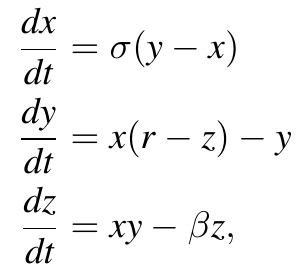


## Desenvolvimento

In [ ]:
df = pd.read_csv("/content/lorenz_kalman_dataset_updated_correct.csv")

df[["x_obs","y_obs","z_obs"]] = df[["x_obs","y_obs","z_obs"]].fillna(0.0)


X = df[["x_bg","y_bg","z_bg",
              "x_obs","y_obs","z_obs"]].values

y = df[["dx_kf","dy_kf","dz_kf"]].values

In [ ]:
df.shape

(10000, 16)

In [ ]:
X = df[["x_bg","y_bg","z_bg",
        "x_obs","y_obs","z_obs"]].values

y = df[["dx_kf","dy_kf","dz_kf"]].values

## Vamos criar um modelo baseado em Redes Neurais para emular o Filtro de alman como método de assimilação de dados para o sistema de Lorenz


### Inicialmente, precisamos dividir o conjunto de dados em duas partes: treino e teste
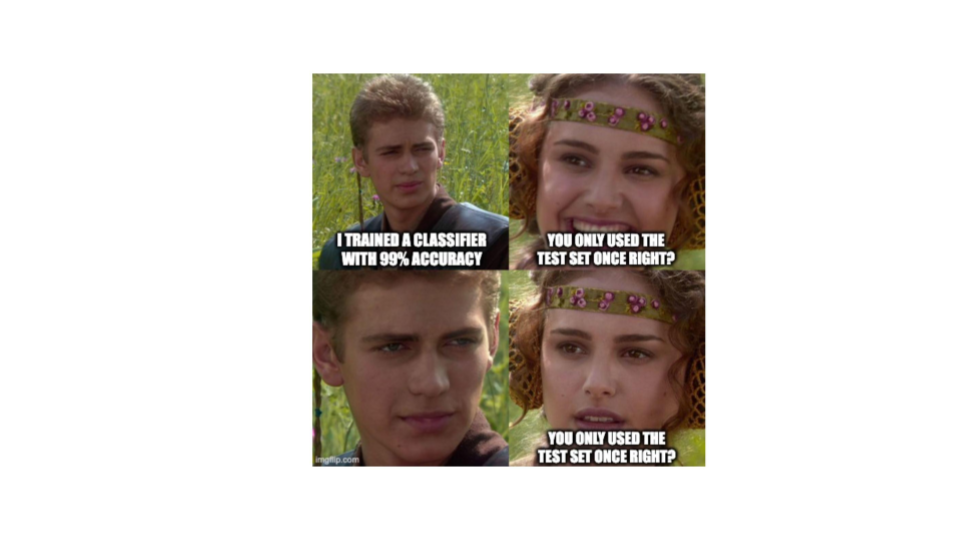

[Leakage and the Reproducibility Crisis in ML-based Science](https://reproducible.cs.princeton.edu/)

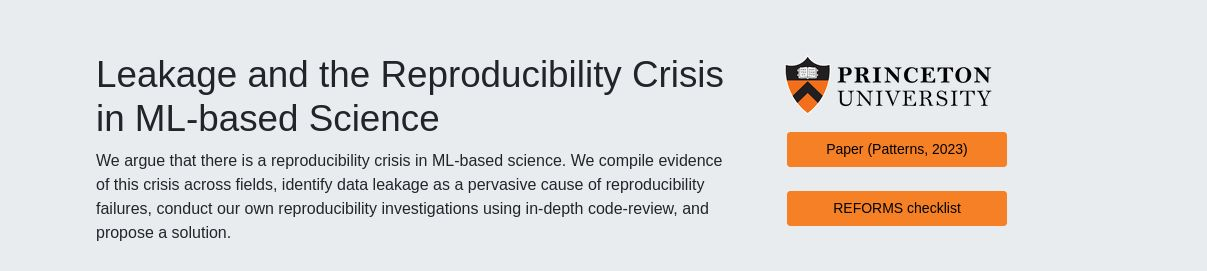

### Construção do conjunto de dados

In [ ]:
train_size = int(0.8 * len(X))

X_train = X[:train_size]
X_test  = X[train_size:]

y_train = y[:train_size]
y_test  = y[train_size:]

In [ ]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled  = scaler_y.transform(y_test)

In [ ]:
sequence_length = 10

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, sequence_length)
X_val_seq, y_val_seq = create_sequences(X_test_scaled, y_test_scaled, sequence_length)

### Definição da arquitetura do modelo

In [ ]:
model = keras.Sequential([
    layers.LSTM(64, input_shape=(sequence_length, 6)),
    layers.Dense(32, activation='relu'),
    layers.Dense(3)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,355 (79.51 KB)

 Trainable params: 20,355 (79.51 KB)

 Non-trainable params: 0 (0.00 B)

### Treinamento

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=1000,
    batch_size=256,
    callbacks=[early_stop]
)

Epoch 1/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.6841 - mae: 0.6514 - val_loss: 0.4591 - val_mae: 0.5443
Epoch 2/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.3938 - mae: 0.4892 - val_loss: 0.4311 - val_mae: 0.5221
Epoch 3/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.3489 - mae: 0.4447 - val_loss: 0.4658 - val_mae: 0.5456
Epoch 4/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.3362 - mae: 0.4278 - val_loss: 0.4408 - val_mae: 0.5277
Epoch 5/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.3240 - mae: 0.4169 - val_loss: 0.4495 - val_mae: 0.5342
Epoch 6/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.3162 - mae: 0.4068 - val_loss: 0.4363 - val_mae: 0.5225
Epoch 7/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.3177 - mae: 0.4057 - val_loss: 0.4340 - val_mae: 0.5187
Epoch 8/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.3091 - mae: 0.3969 - val_loss: 0.4465 - val_mae: 0.5285
Epoch 9/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/

### Avaliação

In [ ]:
test_loss, test_mae = model.evaluate(X_val_seq, y_val_seq)
print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3224 - mae: 0.3970
Test MSE: 0.38202375173568726
Test MAE: 0.4711165130138397


### Predições

In [ ]:
y_pred_scaled = model.predict(X_val_seq)
y_pred = scaler_y.inverse_transform(y_val_seq)

# background correspondente ao último tempo da sequência
x_bg_test = df[["x_bg","y_bg","z_bg"]].values
x_bg_test = x_bg_test[sequence_length + train_size:]

x_analysis_pred = x_bg_test + y_pred
x_analysis_true = df[["x_kf","y_kf","z_kf"]].values
lorenz_true = df[["x_true","y_true","z_true"]].values

lorenz_true = lorenz_true[sequence_length + train_size:]
x_analysis_true = x_analysis_true[sequence_length + train_size:]

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


## Análise dos resultados

### Variável X

#### Adicionando Observações a serem assimiladas

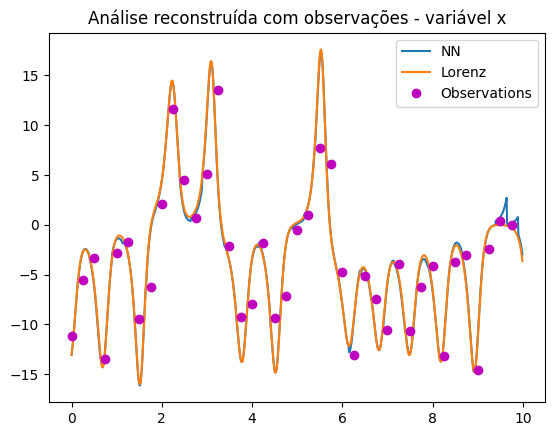

In [ ]:
fmax = len(df)
q = np.arange(0, 1000 * 0.01, 0.01)

start = 0
end   = 1000
dt = 0.01

# Recorte do intervalo
x_obs_slice = X_test[start:end, 3]

# Índices onde há observação
obs_idx = np.where(x_obs_slice != 0)[0]

# Valores das observações
obs_values = x_obs_slice[obs_idx]

# Tempo correspondente
t_obs = obs_idx * dt

# ---- Plot ----
plt.figure()

#plt.plot(q, x_analysis_true[start:end,0], label="KF")
plt.plot(q, x_analysis_pred[start:end,0], label="NN")
#plt.plot(q, x_bg_test[start:end,0], label="BG")
plt.plot(q, lorenz_true[start:end,0], label="Lorenz")

plt.plot(t_obs, obs_values, 'om', label="Observations")

plt.legend()
plt.title("Análise reconstruída com observações - variável x")
plt.show()

#### Removendo observações

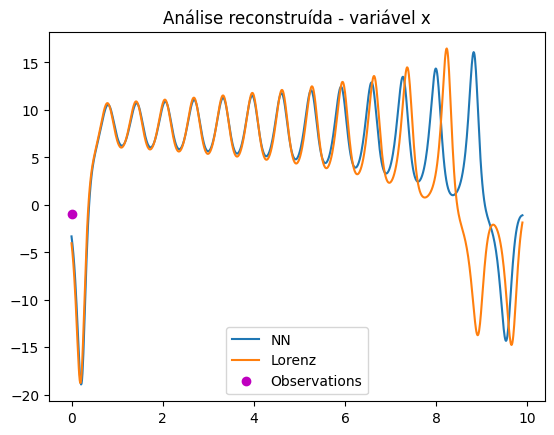

In [ ]:
fmax = len(df)
q = np.arange(0, 990 * 0.01, 0.01)

start = 1000
end   = 2000
dt = 0.01

# Recorte do intervalo
x_obs_slice = X_test[start:end, 3]

# Índices onde há observação
obs_idx = np.where(x_obs_slice != 0)[0]

# Valores das observações
obs_values = x_obs_slice[obs_idx]

# Tempo correspondente
t_obs = obs_idx * dt

# ---- Plot ----
plt.figure()

#plt.plot(q, x_analysis_true[start:end,0], label="KF")
plt.plot(q, x_analysis_pred[start:end,0], label="NN")
#plt.plot(q, x_bg_test[start:end,0], label="BG")
plt.plot(q, lorenz_true[start:end,0], label="Lorenz")

plt.plot(t_obs, obs_values, 'om', label="Observations")

plt.legend()
plt.title("Análise reconstruída - variável x")
plt.show()